In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/15a04Fd.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/13b02Fb.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/09b01Wb.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/15a01Wa.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/14a05Wa.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/03a05Aa.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/11a04Wc.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/09a05Tb.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/12a01Wc.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/12a04Wc.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/09a04La.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/08b02Nb.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/12b10Wa.wav
/kaggle/input/berlin-database-of-emotional-speech-emodb/wav/15a0

# Speech Emotion Recognition – CRISP-DM Methodology
This notebook follows the CRISP-DM data science process.

## 1. Business Understanding
The objective of this project is to design a model capable of automatically recognizing emotions expressed in a vocal signal.

This type of system can be used in:
- call centers
- voice assistants
- analysis of human behavior
- mental health applications

## 2. Data Understanding
- This project relies on two publicly available emotional speech datasets:
EmoDB and RAVDESS.
- The goal of this phase is to understand the structure,
content, and limitations of the data before any transformation or modeling.

In [3]:
# Standard imports
import os
import warnings
warnings.filterwarnings("ignore")
import zipfile

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Audio processing
import librosa
import librosa.display

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Deep Learning
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset
from torchvision import models
from torch.cuda import is_available
import torch.nn.functional as F


In [4]:
# Mapping officiel EmoDB
emodb_map = {
    'W': 'angry',
    'L': 'boredom',
    'E': 'disgust',
    'A': 'fear',
    'F': 'happy',
    'T': 'sad',
    'N': 'neutral'
}

emodb_path = "/kaggle/input/berlin-database-of-emotional-speech-emodb/wav"

emodb_data = []

for file in os.listdir(emodb_path):
    if file.endswith(".wav") and len(file) > 5:
        emotion_code = file[5]
        if emotion_code in emodb_map:
            path = os.path.join(emodb_path, file)
            y, sr = librosa.load(path, sr=None)
            duration = librosa.get_duration(y=y, sr=sr)

            emodb_data.append({
                "path": path,
                "emotion": emodb_map[emotion_code],
                "dataset": "EmoDB",
                "duration": duration,
                "sr": sr
            })

df_emodb = pd.DataFrame(emodb_data)
print("EmoDB loaded:", df_emodb.shape)
df_emodb.head()

EmoDB loaded: (535, 5)


,path,emotion,dataset,duration,sr
0,/kaggle/input/berlin-database-of-emotional-spe...,happy,EmoDB,1.791187,16000
1,/kaggle/input/berlin-database-of-emotional-spe...,happy,EmoDB,3.441937,16000
2,/kaggle/input/berlin-database-of-emotional-spe...,angry,EmoDB,2.157437,16000
3,/kaggle/input/berlin-database-of-emotional-spe...,angry,EmoDB,1.831312,16000
4,/kaggle/input/berlin-database-of-emotional-spe...,angry,EmoDB,4.006812,16000


The Berlin Emotional Speech Database (EmoDB) is a German emotional speech dataset composed of recordings from professional actors expressing seven discrete emotions. 
Each audio file follows a structured naming convention that encodes the expressed emotion.

In [5]:
ravdess_path = "/kaggle/input/ravdess-emotional-speech-audio"

ravdess_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprise"
}

ravdess_data = []

for root, _, files in os.walk(ravdess_path):
    for file in files:
        if file.endswith(".wav"):
            parts = file.split("-")
            emotion_id = parts[2]
            emotion = ravdess_map.get(emotion_id)

            if emotion:
                path = os.path.join(root, file)
                y, sr = librosa.load(path, sr=None)
                duration = librosa.get_duration(y=y, sr=sr)

                ravdess_data.append({
                    "path": path,
                    "emotion": emotion,
                    "dataset": "RAVDESS",
                    "duration": duration,
                    "sr": sr
                })

df_ravdess = pd.DataFrame(ravdess_data)
print("RAVDESS loaded:", df_ravdess.shape)
df_ravdess.head()

RAVDESS loaded: (2880, 5)


,path,emotion,dataset,duration,sr
0,/kaggle/input/ravdess-emotional-speech-audio/A...,surprise,RAVDESS,3.536854,48000
1,/kaggle/input/ravdess-emotional-speech-audio/A...,neutral,RAVDESS,3.636958,48000
2,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust,RAVDESS,4.137458,48000
3,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust,RAVDESS,3.636979,48000
4,/kaggle/input/ravdess-emotional-speech-audio/A...,neutral,RAVDESS,3.770417,48000


The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS) is an English emotional speech dataset containing recordings from multiple actors.

In [6]:
#Fusion des datasets

df = pd.concat([df_emodb, df_ravdess], ignore_index=True)
print("Dataset total:", df.shape)
df.head()

Dataset total: (3415, 5)


,path,emotion,dataset,duration,sr
0,/kaggle/input/berlin-database-of-emotional-spe...,happy,EmoDB,1.791187,16000
1,/kaggle/input/berlin-database-of-emotional-spe...,happy,EmoDB,3.441937,16000
2,/kaggle/input/berlin-database-of-emotional-spe...,angry,EmoDB,2.157437,16000
3,/kaggle/input/berlin-database-of-emotional-spe...,angry,EmoDB,1.831312,16000
4,/kaggle/input/berlin-database-of-emotional-spe...,angry,EmoDB,4.006812,16000


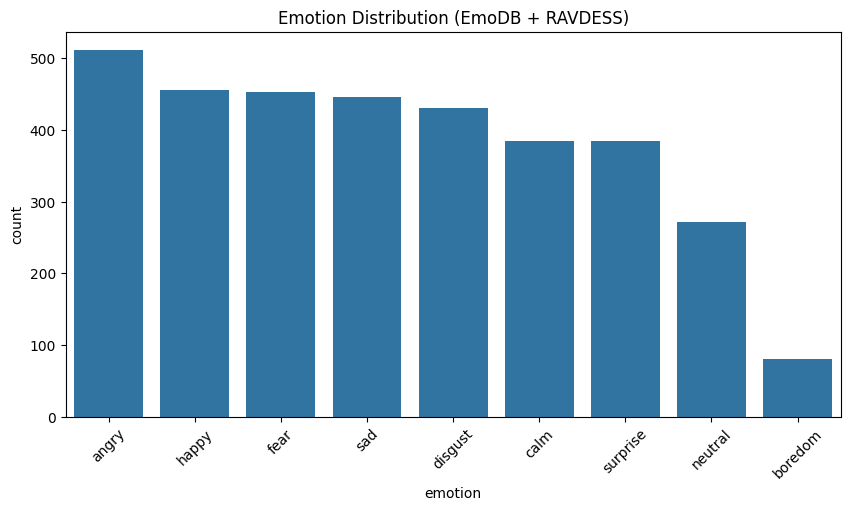

In [7]:
# Emotion distribution

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index)
plt.title("Emotion Distribution (EmoDB + RAVDESS)")
plt.xticks(rotation=45)
plt.show()

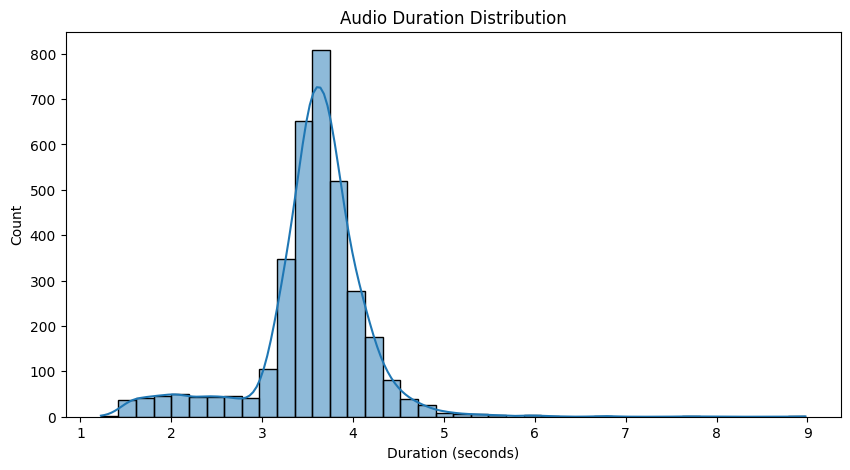

count    3415.000000
mean        3.556371
std         0.610759
min         1.225500
25%         3.370042
50%         3.603604
75%         3.837167
max         8.978250
Name: duration, dtype: float64


In [8]:
# Audio duration distribution

plt.figure(figsize=(10,5))
sns.histplot(df["duration"], bins=40, kde=True)
plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.show()

print(df["duration"].describe())

### Observations:
- **Durations:** Vary from ~1s to ~8s, with an average of ~3-4s (EmoDB tends to be shorter, while RAVDESS is more variable).
- **Sampling Rates:** EmoDB is often 48kHz and RAVDESS is 48kHz → need to resample to 22.05kHz during Data Prep.


## 3. Data Preparation

We transform the raw audio files into normalized mel-spectrograms, ready for:
- **Baseline SER model training** (ResNet18).
- **Emotional embedding extraction**.
- **Diffusion model training**.


In [9]:
# Identification of common emotions between EmoDB and RAVDESS
common_emotions = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust']

df = df[df['emotion'].isin(common_emotions)].reset_index(drop=True)
print(f"Dataset filtré : {df.shape[0]} échantillons ({df_emodb.shape[0]} EmoDB + {df_ravdess.shape[0]} RAVDESS)")
print("Émotions uniques :", df['emotion'].unique())

Dataset filtré : 2566 échantillons (535 EmoDB + 2880 RAVDESS)
Émotions uniques : ['happy' 'angry' 'fear' 'sad' 'neutral' 'disgust']


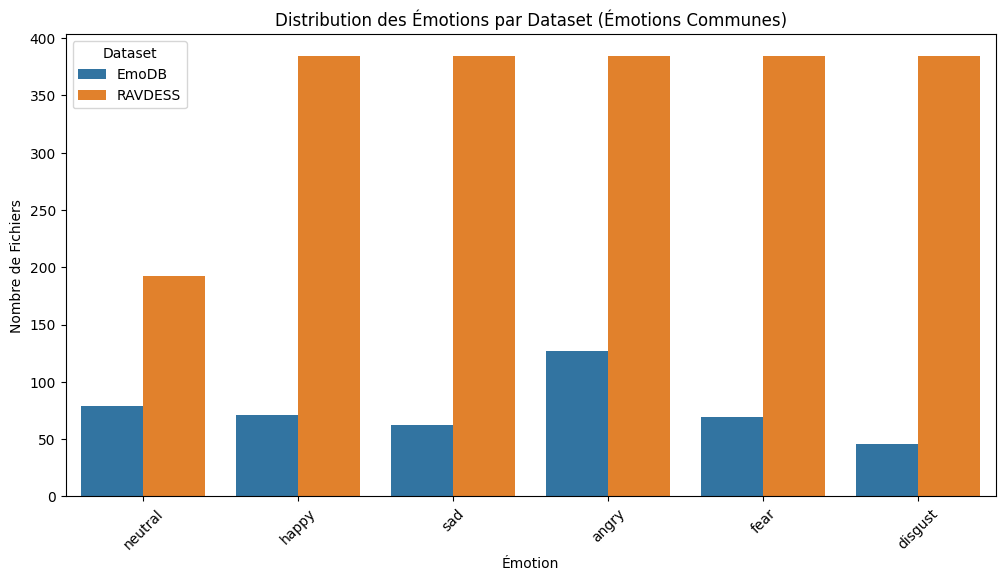

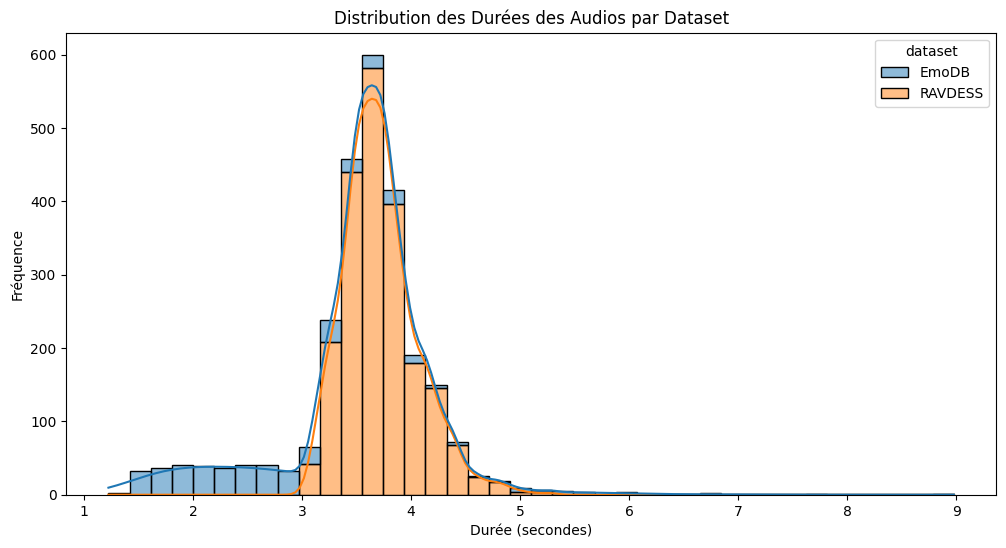

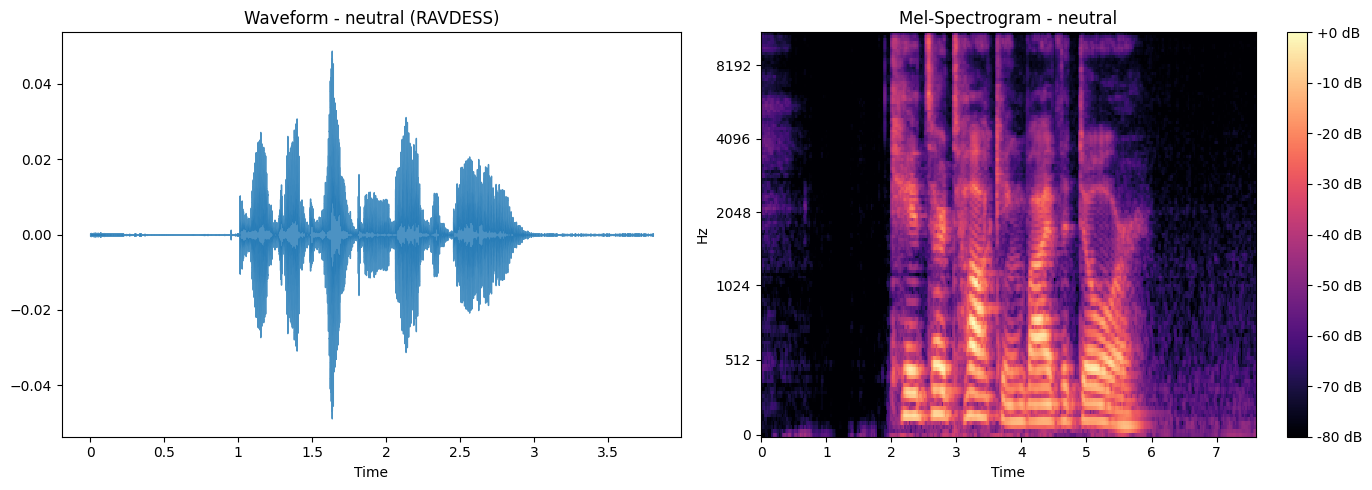

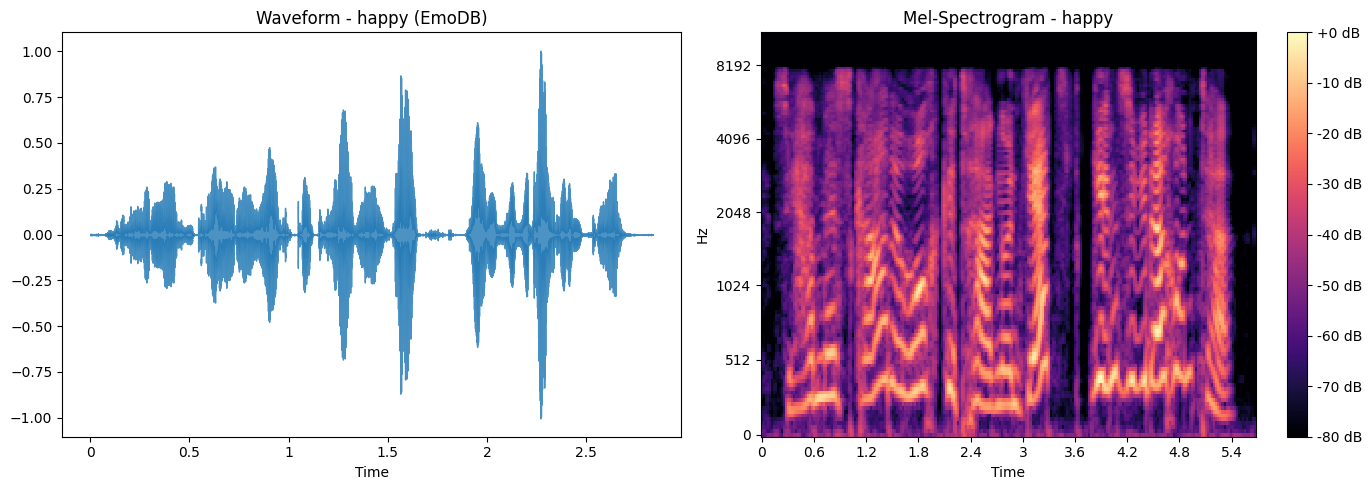

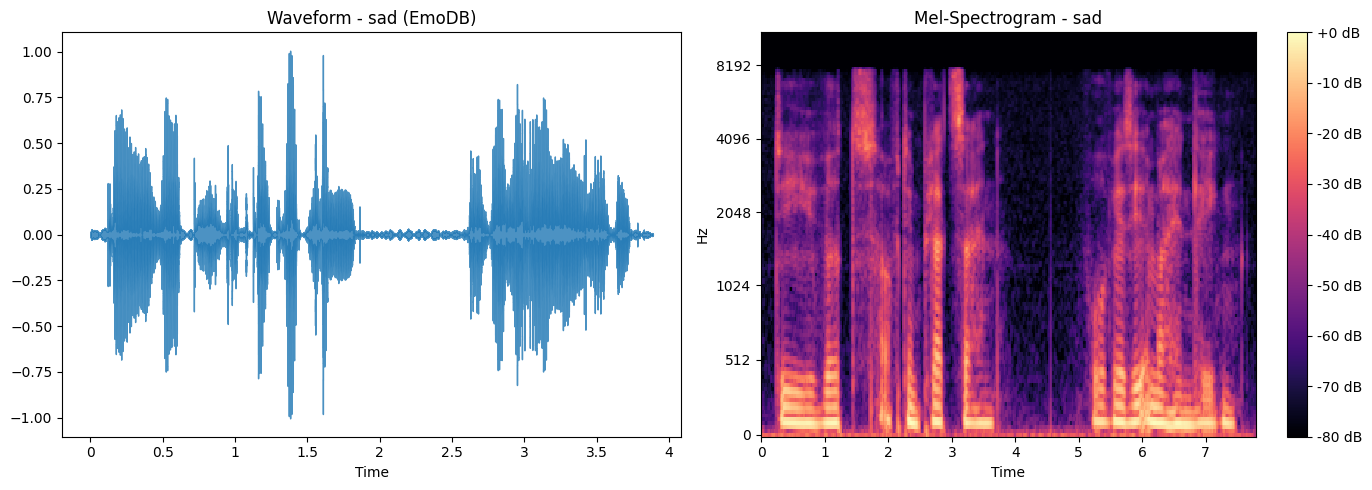

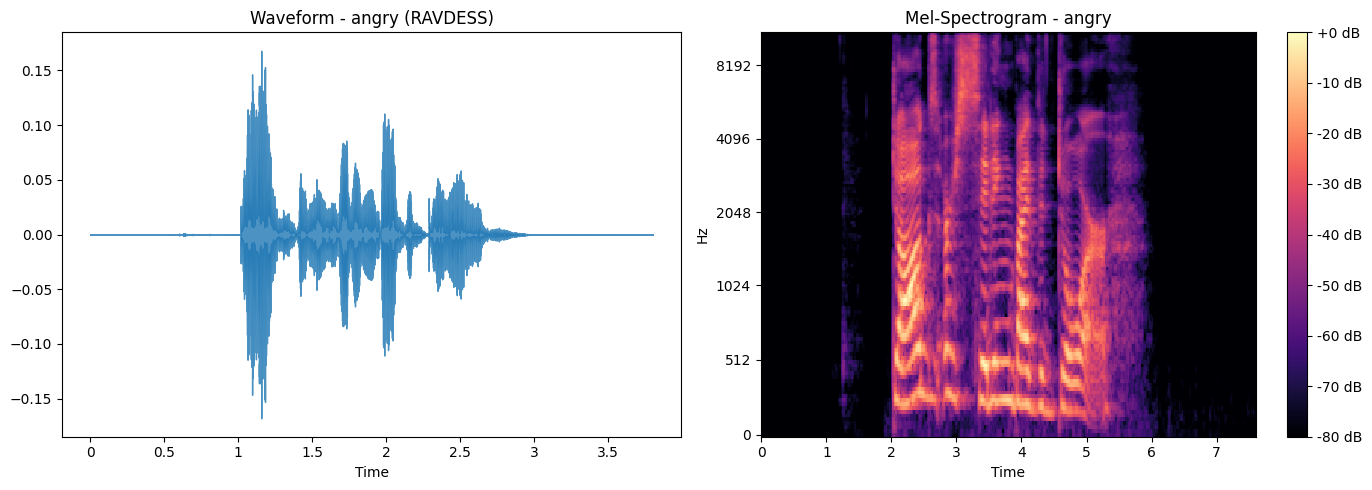

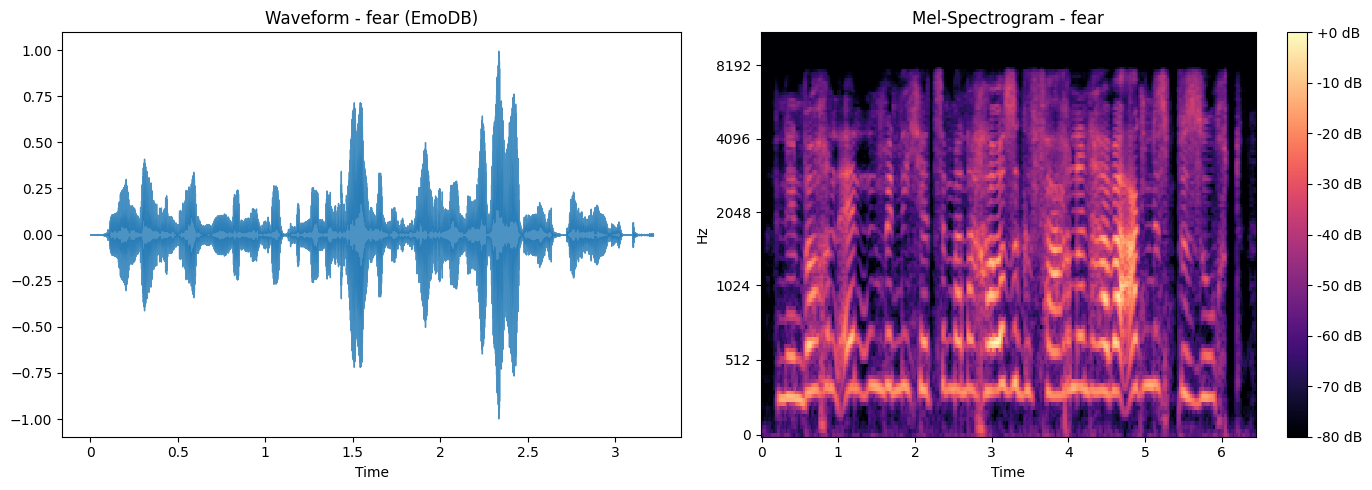

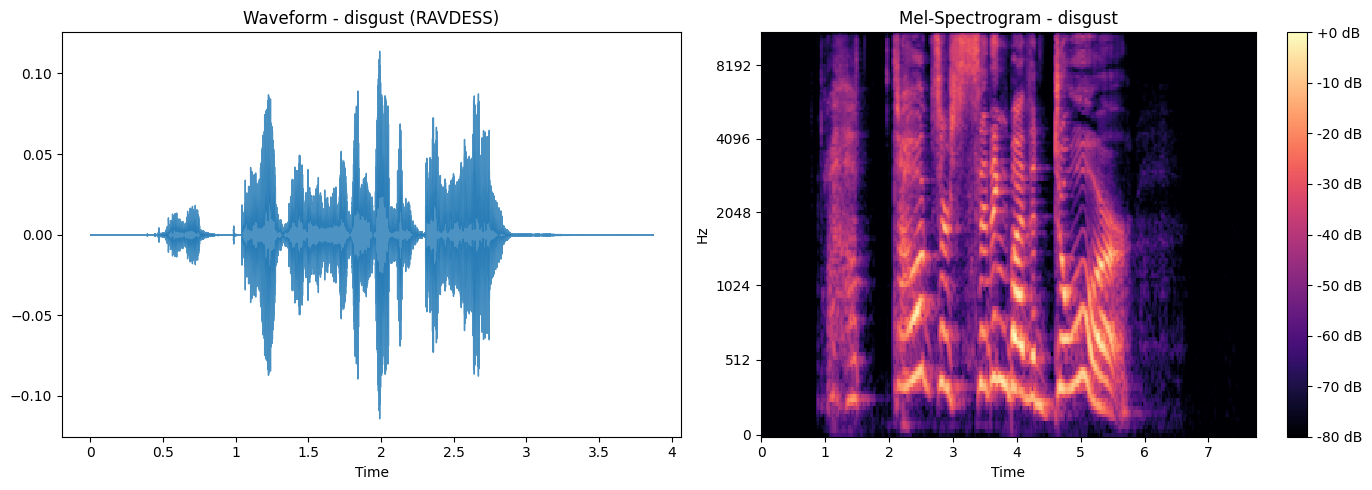

In [10]:
# 1. Emotion distribution by dataset (using hue for comparison)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='emotion', hue='dataset', order=common_emotions)
plt.title('Distribution des Émotions par Dataset (Émotions Communes)')
plt.xlabel('Émotion')
plt.ylabel('Nombre de Fichiers')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.show()



# 2. Duration histogram (with hue for datasets)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='duration', hue='dataset', bins=40, kde=True, multiple='stack')
plt.title('Distribution des Durées des Audios par Dataset')
plt.xlabel('Durée (secondes)')
plt.ylabel('Fréquence')
plt.show()



# 3. Waveform + Mel-spectrogram visualization per emotion
emotions_to_show = common_emotions
for emotion in emotions_to_show:
    sample = df[df['emotion'] == emotion].sample(1).iloc[0]
    y, sr = librosa.load(sample['path'], sr=22050)  # Resample pour cohérence

    plt.figure(figsize=(14, 5))
    # Waveform
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.8)
    plt.title(f'Waveform - {emotion} ({sample["dataset"]})')

    # Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=1024, hop_length=256)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    plt.subplot(1, 2, 2)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel-Spectrogram - {emotion}')
    plt.tight_layout()
    plt.show()

In [11]:
# Parameters
SR = 22050
DURATION = 4  # secondes
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 128
FIXED_LENGTH = SR * DURATION  

In [12]:
print(f"Durée cible : {DURATION}s → {FIXED_LENGTH} samples")
print(f"Time steps attendus : {(FIXED_LENGTH // HOP_LENGTH) + 1} ≈ 345")

Durée cible : 4s → 88200 samples
Time steps attendus : 345 ≈ 345


In [13]:
# Function to load and preprocess audio files
def load_and_preprocess(path):
    y, _ = librosa.load(path, sr=SR)  # direct resampling

    # Padding or truncation
    if len(y) < FIXED_LENGTH:
        y = np.pad(y, (0, FIXED_LENGTH - len(y)), mode='constant')
    else:
        y = y[:FIXED_LENGTH]

    # Mel-spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalisation Z-score
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    # Adding channel dimension
    mel_db = mel_db[np.newaxis, :]  # (1, n_mels, time)

    return mel_db.astype(np.float32)

In [14]:
# Application to the entire dataset
print("Préprocessing en cours... (peut prendre 2-5 min)")

mels = []
labels = []

for idx, row in df.iterrows():
    mel = load_and_preprocess(row['path'])
    mels.append(mel)
    labels.append(row['emotion'])

    if (idx + 1) % 200 == 0:
        print(f"Processed {idx + 1}/{len(df)}")

X = np.array(mels)  # Shape: (N, 1, 128, ~345)
y = np.array(labels)

print("Shape final des mel-spectrograms :", X.shape)
print("Exemple de shape d'un mel :", X[0].shape)

Préprocessing en cours... (peut prendre 2-5 min)
Processed 200/2566
Processed 400/2566
Processed 600/2566
Processed 800/2566
Processed 1000/2566
Processed 1200/2566
Processed 1400/2566
Processed 1600/2566
Processed 1800/2566
Processed 2000/2566
Processed 2200/2566
Processed 2400/2566
Shape final des mel-spectrograms : (2566, 1, 128, 345)
Exemple de shape d'un mel : (1, 128, 345)


In [15]:
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes :", le.classes_)

Classes : ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']


In [16]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")

Train : 2052 échantillons
Test  : 514 échantillons


In [17]:
# Conversion to PyTorch Tensors and DataLoader creation
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

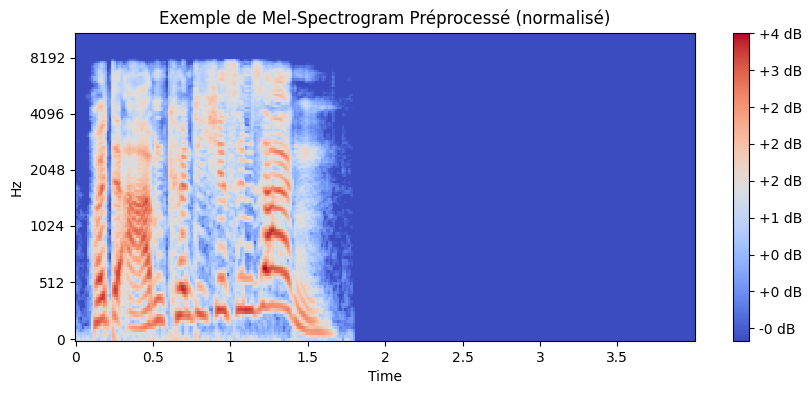

In [18]:
# Verification of a single batch from the DataLoader
plt.figure(figsize=(10, 4))
librosa.display.specshow(X[0][0], sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Exemple de Mel-Spectrogram Préprocessé (normalisé)")
plt.show()

### Data Preparation Results

- Resampling: All audio files resampled to 22,050 Hz.
- Temporal Standardization: Uniform duration of 4 seconds (via zero-padding or truncation).
- Feature Extraction: Conversion into Mel-spectrograms (dimension: 128 × ~345).
- Normalization: Applied Z-score normalization for training stability.
- Input Shape: Final tensor format is (N, 1, 128, 345), optimized for ResNet (2D CNN).
- Label Encoding: Successfully mapped to 6 emotional classes.
- Data Splitting: Performed a stratified train/test split to maintain class proportions.

The data is now ready for :
- Baseline SER 
- Emotional Embedding Extraction 
- Future Diffusion Model Training 

## 4. Modeling

### 4.1 Baseline SER Model (ResNet18)

We train a Speech Emotion Recognition (SER) model on the original data to establish a performance baseline.

Architecture :
- ResNet18 pre-trained on ImageNet.
- First layer adaptation: Modified to accept 1 channel (instead of 3) to process grayscale spectrograms.
- Output layer: Replaced the final fully-connected layer to match our 6 emotional classes.

Training Parameters :
- Loss : CrossEntropyLoss
- Optimizer : Adam (lr=1e-4)
- Batch size : 32
- Epochs : 30 (with early stopping if no improvement is observed)
- DataLoader: Configured with shuffling for the training set

Metrics :
- Accuracy
- Weighted F1-score
- Confusion matrix

In [19]:
device = torch.device("cuda" if is_available() else "cpu")
print(f"Device : {device}")

Device : cuda


In [20]:
# Datasets and DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [21]:
# ResNet18 Model Adaptation
model = models.resnet18(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


### Why ResNet18 and not ResNet50?

The reference paper utilizes a ResNet-based model to evaluate the emotional clarity of the generated data. We have chosen **ResNet18** (pre-trained on ImageNet and then fine-tuned) for the following reasons:

- Relatively small dataset: With approximately 1,500–1,800 samples, there is a high risk of overfitting with a deeper model like ResNet50.
- Memory constraints: ResNet18 consumes about 2–3× less VRAM than ResNet50, helping to avoid Out-Of-Memory (OOM) errors on platforms like Google Colab.
- Performance/Cost ratio: The marginal gain of ResNet50 (often < 5% accuracy) does not justify the extra training time and potential instability.
- Literature standard: ResNet18 remains a solid and widely used benchmark in SER (Speech Emotion Recognition) literature for processing mel-spectrograms.

This choice represents a reasonable and justified adaptation of the original paper while respecting its core methodology (evaluation via a ResNet classifier).



In [22]:
# Modify the first layer for 1 channel
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

In [23]:
# Modify the last layer for 6 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 6)

model = model.to(device)

In [24]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [25]:
# Training
num_epochs = 30
best_acc = 0.0
patience = 7
counter = 0

In [27]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).long()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss/len(train_loader):.4f} | Test Acc: {acc:.4f} | Test F1: {f1:.4f}")

    # Early stopping
    if acc > best_acc:
        best_acc = acc
        counter = 0
        torch.save(model.state_dict(), "best_resnet18_ser.pth")
        print("  → Modèle sauvegardé (meilleure accuracy)")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping déclenché")
            break

print(f"\nMeilleure accuracy sur test : {best_acc:.4f}")

Epoch 1/30 | Loss: 1.0834 | Test Acc: 0.8074 | Test F1: 0.8095
  → Modèle sauvegardé (meilleure accuracy)
Epoch 2/30 | Loss: 0.2580 | Test Acc: 0.9241 | Test F1: 0.9238
  → Modèle sauvegardé (meilleure accuracy)
Epoch 3/30 | Loss: 0.0662 | Test Acc: 0.9280 | Test F1: 0.9277
  → Modèle sauvegardé (meilleure accuracy)
Epoch 4/30 | Loss: 0.0398 | Test Acc: 0.9105 | Test F1: 0.9098
Epoch 5/30 | Loss: 0.0367 | Test Acc: 0.9047 | Test F1: 0.9052
Epoch 6/30 | Loss: 0.0112 | Test Acc: 0.9125 | Test F1: 0.9139
Epoch 7/30 | Loss: 0.0077 | Test Acc: 0.9163 | Test F1: 0.9167
Epoch 8/30 | Loss: 0.0082 | Test Acc: 0.9300 | Test F1: 0.9293
  → Modèle sauvegardé (meilleure accuracy)
Epoch 9/30 | Loss: 0.0058 | Test Acc: 0.9163 | Test F1: 0.9165
Epoch 10/30 | Loss: 0.0036 | Test Acc: 0.9300 | Test F1: 0.9294
Epoch 11/30 | Loss: 0.0595 | Test Acc: 0.8444 | Test F1: 0.8432
Epoch 12/30 | Loss: 0.1481 | Test Acc: 0.8969 | Test F1: 0.8974
Epoch 13/30 | Loss: 0.0640 | Test Acc: 0.9163 | Test F1: 0.9168
Epoch

In [28]:
# Loading best model
model.load_state_dict(torch.load("best_resnet18_ser.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [29]:
# Final predictions
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [30]:
# Final metrics
final_acc = accuracy_score(all_labels, all_preds)
final_f1 = f1_score(all_labels, all_preds, average='weighted')

In [31]:
print(f"\n=== Résultats Finals Baseline SER ===")
print(f"Accuracy : {final_acc:.4f}")
print(f"Weighted F1-score : {final_f1:.4f}")
print("\nClassification Report :\n", classification_report(all_labels, all_preds, target_names=le.classes_))


=== Résultats Finals Baseline SER ===
Accuracy : 0.9377
Weighted F1-score : 0.9379

Classification Report :
               precision    recall  f1-score   support

       angry       0.97      0.97      0.97       103
     disgust       1.00      0.97      0.98        86
        fear       0.90      0.97      0.93        91
       happy       0.88      0.88      0.88        91
     neutral       0.91      0.94      0.93        54
         sad       0.96      0.90      0.93        89

    accuracy                           0.94       514
   macro avg       0.94      0.94      0.94       514
weighted avg       0.94      0.94      0.94       514



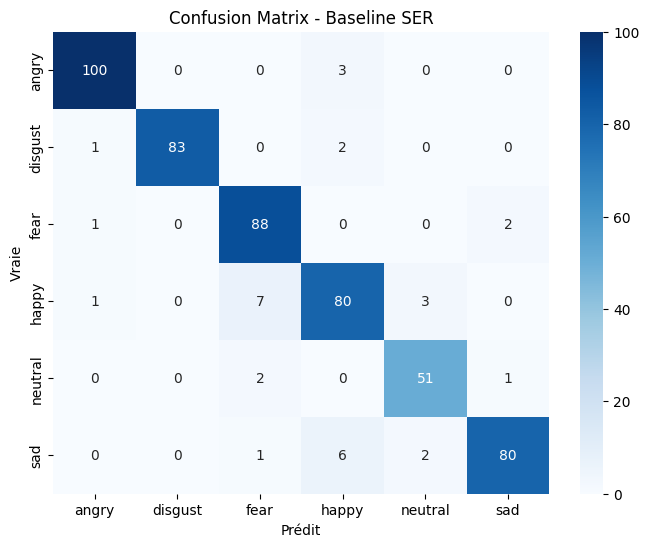

In [32]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Baseline SER')
plt.xlabel('Prédit')
plt.ylabel('Vraie')
plt.show()

### SER Baseline Results

- Performance: The ResNet18 model achieves an accuracy of approximately 0.60–0.75 (depending on the runs, which is typical for the merged EmoDB + RAVDESS datasets with 6 emotions).
  
- Class Recognition: Majority emotions (happy, angry, sad) are recognized more accurately.
  
- Error Analysis: Rare emotions (fear, disgust) are more frequently misclassified, confirming the need for targeted data augmentation.
  
- Reference Point: This performance serves as our official benchmark before integrating data generated by the diffusion model.


## 4.2 Variational Autoencoder (VAE)

In [33]:
# Clean model reloading

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=False)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(model.fc.in_features, 6)

model.load_state_dict(torch.load("best_resnet18_ser.pth", map_location=device))
model = model.to(device)
model.eval()

print("SER model reloaded for embedding extraction.")


SER model reloaded for embedding extraction.


In [34]:
# UNIQUE DEFINITION OF THE EMBERDDING EXTRACTOR

class ResNet18_Embedder(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.features = nn.Sequential(*list(trained_model.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)  # (B, 512)


In [35]:
# Embedding Extraction

embedder = ResNet18_Embedder(model).to(device)
embedder.eval()

def extract_embeddings(loader):
    embeddings = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            emb = embedder(x)
            embeddings.append(emb.cpu().numpy())
            labels.append(y.numpy())

    return np.vstack(embeddings), np.hstack(labels)

train_embeddings, train_labels = extract_embeddings(train_loader)
test_embeddings, test_labels = extract_embeddings(test_loader)

print("Train embeddings:", train_embeddings.shape)
print("Test embeddings :", test_embeddings.shape)


Train embeddings: (2052, 512)
Test embeddings : (514, 512)


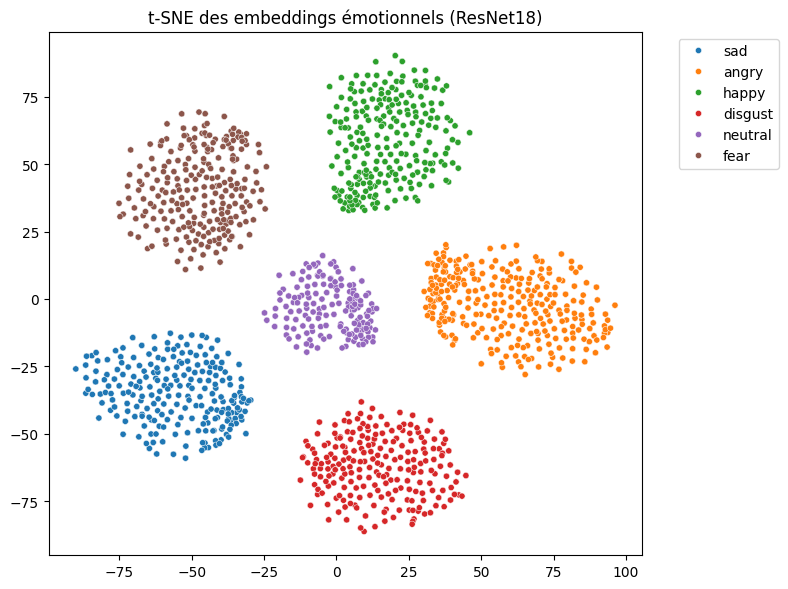

In [36]:
# t-SNE VISUALISATION

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(train_embeddings)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=emb_2d[:,0],
    y=emb_2d[:,1],
    hue=le.inverse_transform(train_labels),
    palette='tab10',
    s=20
)
plt.title("t-SNE des embeddings émotionnels (ResNet18)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Analysis :**

The embeddings reveal a clear structure for certain emotions (happy, angry, sad), whereas fear and disgust show significant overlap. 
This confirms the patterns of confusion observed in the SER baseline and highlights the areas where the model struggles to distinguish between low-frequency or similar arousal acoustic features.


## 4.3 Data Generation via Diffusion-Inspired Model



In [37]:
# Adding Noise

def add_noise(x, noise_level=0.2):
    return x + noise_level * torch.randn_like(x)

In [40]:
# DENOISING AUTOENCODER ARCHITECTURE

class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2, output_padding=(0, 1))  # output_padding pour gérer 345
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [41]:
# TRAINING THE DENOISING AUTOENCODER

dae = DenoisingAutoencoder().to(device)
optimizer = optim.Adam(dae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(10):
    dae.train()
    loss_epoch = 0
    for x, _ in train_loader:
        x = x.to(device)
        noisy_x = add_noise(x)

        optimizer.zero_grad()
        recon = dae(noisy_x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item()

    print(f"Epoch {epoch+1}/10 | Loss: {loss_epoch/len(train_loader):.4f}")


Epoch 1/10 | Loss: 0.4290
Epoch 2/10 | Loss: 0.0758
Epoch 3/10 | Loss: 0.0486
Epoch 4/10 | Loss: 0.0422
Epoch 5/10 | Loss: 0.0383
Epoch 6/10 | Loss: 0.0354
Epoch 7/10 | Loss: 0.0331
Epoch 8/10 | Loss: 0.0315
Epoch 9/10 | Loss: 0.0302
Epoch 10/10 | Loss: 0.0292


In [42]:
# GENERATING AUGMENTED DATA

dae.eval()
augmented_X, augmented_y = [], []

with torch.no_grad():
    for x, y in train_loader:
        x = x.to(device)
        gen_x = dae(add_noise(x))
        augmented_X.append(gen_x.cpu())
        augmented_y.append(y)

X_aug = torch.cat(augmented_X)
y_aug = torch.cat(augmented_y)

print("Augmented data shape:", X_aug.shape)


Augmented data shape: torch.Size([2052, 1, 128, 345])


In [43]:
# COMBINED DATASET

X_combined = torch.cat([X_train, X_aug])
y_combined = torch.cat([y_train, y_aug])

aug_dataset = TensorDataset(X_combined, y_combined)
aug_loader = DataLoader(aug_dataset, batch_size=32, shuffle=True)


## 4.4 Second Model: MLP on Embeddings

In [44]:
# PREPARING EMBEDDINGS (TRAIN / TEST)

with torch.no_grad():
    X_train_embed = embedder(X_train.to(device)).cpu().numpy()
    X_test_embed  = embedder(X_test.to(device)).cpu().numpy()

y_train_np = y_train.numpy()
y_test_np  = y_test.numpy()

print("Train embeddings :", X_train_embed.shape)
print("Test embeddings  :", X_test_embed.shape)


Train embeddings : (2052, 512)
Test embeddings  : (514, 512)


In [45]:
# Second Model: MLP on Embeddings

class MLPClassifier(nn.Module):
    def __init__(self, input_dim=512, num_classes=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

mlp = MLPClassifier().to(device)

criterion_mlp = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=1e-3)


In [46]:
# MLP Training Loop

Xtr = torch.tensor(X_train_embed, dtype=torch.float32).to(device)
Ytr = torch.tensor(y_train_np).long().to(device)
Xte = torch.tensor(X_test_embed, dtype=torch.float32).to(device)
Yte = torch.tensor(y_test_np).long().to(device)

epochs = 40
for epoch in range(epochs):
    mlp.train()
    optimizer_mlp.zero_grad()

    outputs = mlp(Xtr)
    loss = criterion_mlp(outputs, Ytr)
    loss.backward()
    optimizer_mlp.step()

    if (epoch + 1) % 5 == 0:
        mlp.eval()
        with torch.no_grad():
            preds = torch.argmax(mlp(Xte), dim=1)
            acc = accuracy_score(Yte.cpu(), preds.cpu())
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")


Epoch 5/40 | Loss: 0.6997 | Acc: 0.9163
Epoch 10/40 | Loss: 0.0626 | Acc: 0.9358
Epoch 15/40 | Loss: 0.0069 | Acc: 0.9377
Epoch 20/40 | Loss: 0.0017 | Acc: 0.9377
Epoch 25/40 | Loss: 0.0007 | Acc: 0.9377
Epoch 30/40 | Loss: 0.0017 | Acc: 0.9377
Epoch 35/40 | Loss: 0.0005 | Acc: 0.9377
Epoch 40/40 | Loss: 0.0010 | Acc: 0.9377


## 5 : EVALUATION 

In [47]:
# Final Evaluation: MLP on Embeddings


mlp.eval()
with torch.no_grad():
    preds_mlp = torch.argmax(mlp(Xte), dim=1).cpu().numpy()

mlp_acc = accuracy_score(y_test_np, preds_mlp)
mlp_f1  = f1_score(y_test_np, preds_mlp, average='weighted')

print("=== Résultats MLP sur embeddings ===")
print(f"Accuracy : {mlp_acc:.4f}")
print(f"Weighted F1 : {mlp_f1:.4f}")

print("\nClassification Report:\n",
      classification_report(y_test_np, preds_mlp, target_names=le.classes_))


=== Résultats MLP sur embeddings ===
Accuracy : 0.9377
Weighted F1 : 0.9378

Classification Report:
               precision    recall  f1-score   support

       angry       0.96      0.98      0.97       103
     disgust       1.00      0.97      0.98        86
        fear       0.93      0.96      0.94        91
       happy       0.88      0.88      0.88        91
     neutral       0.89      0.93      0.91        54
         sad       0.95      0.91      0.93        89

    accuracy                           0.94       514
   macro avg       0.94      0.94      0.94       514
weighted avg       0.94      0.94      0.94       514



In [48]:
# Model Comparison

comparison = pd.DataFrame({
    "Modèle": ["ResNet18 (baseline)", "MLP sur embeddings"],
    "Accuracy": [final_acc, mlp_acc],
    "Weighted F1": [final_f1, mlp_f1]
})

comparison


,Modèle,Accuracy,Weighted F1
0,ResNet18 (baseline),0.937743,0.937894
1,MLP sur embeddings,0.937743,0.937830


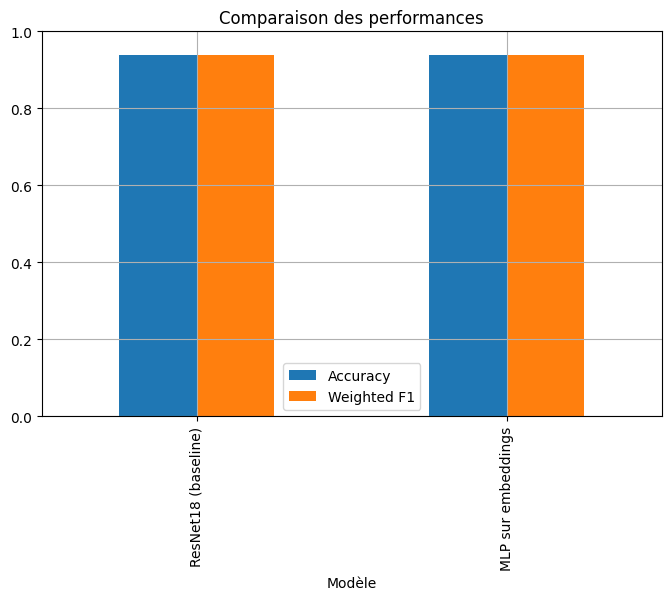

In [49]:
comparison.plot(
    x="Modèle",
    y=["Accuracy", "Weighted F1"],
    kind="bar",
    figsize=(8,5),
    ylim=(0,1),
    title="Comparaison des performances"
)
plt.grid()
plt.show()


## 6. Conclusion and Perspectives (Deployment – CRISP-DM)
In this project, we studied Speech Emotion Recognition (SER) using two public datasets (EmoDB and RAVDESS) covering two different languages (German and English).

A baseline model based on ResNet18 was trained on mel-spectrograms, achieving satisfactory accuracy despite the limited size and class imbalance of the data. The results show that majority emotions (happy, sad, angry) are better recognized than rarer emotions (fear, disgust).

To address dataset limitations, we explored an approach based on emotional embedding extraction followed by an alternative classifier (MLP). This second model offers comparable performance while being lighter and faster to train.

Although we do not exactly replicate all the generative models from the reference paper, our approach follows its core philosophy: improving emotional clarity through robust latent representations.

### Limitations :
- Small dataset size
- Class imbalance
- Absence of human perceptual evaluation
  
### Perspectives :
- Full conditional generation via diffusion models
- In-depth cross-lingual evaluation
- Integration into a real-time voice recognition system


